# Optimal Transport in linear ICA: EEG Artifact Removal
#### In this application, we apply OT-ICA to a real-world clinical EEG dataset to demonstrate its ability to isolate sparse, super-Gaussian biological artifacts (like eye-blinks) from continuous brain wave recordings.

### The Challenge of Volume Conduction
In EEG recordings, the human skull acts as a linear volume conductor. This means the electrical signals generated by various brain regions, as well as non-brain muscles (like the eyes and jaw), mix instantaneously and linearly before reaching the scalp electrodes. This perfectly satisfies the foundational linear mixing model: $X = AS$.

Eye blinks (ocular artifacts) are notoriously problematic in neuroscience because their high amplitude completely masks the underlying cognitive brain waves. However, because eye blinks are mathematically highly sparse and "super-Gaussian", ICA is the gold-standard technique for isolating and removing them.

In this notebook, we use the `mne` library to fetch a real clinical MEG/EEG sample dataset, and deploy OT-ICA to blindly separate the blink artifact into a single independent component.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import mne
import warnings
warnings.filterwarnings('ignore')

from wasserstein_ica import WassersteinICA

# ==========================================
# 1. Thesis Theme Configuration
# ==========================================
def set_thesis_theme():
    plt.rcParams.update({
        'figure.figsize': (24, 16), # Massive figure size
        'figure.dpi': 300,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.size': 24,            # Doubled base font size
        'lines.linewidth': 2.5      # Thickened, but careful not to blur EEG waves
    })
set_thesis_theme()

In [2]:
# ==========================================
# 2. Fetch and Load Real Clinical EEG Data
# ==========================================
print("Fetching MNE Sample Dataset...")
# Note: MNE will download the data on the first run to ~/mne_data, and load from cache thereafter.
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / 'MEG' / 'sample' / 'sample_audvis_raw.fif'

# Load the raw data file
raw = mne.io.read_raw_fif(sample_data_raw_file, preload=True, verbose=False)

# Filter the data (1Hz to 40Hz is standard for ICA to remove slow drifts and high-frequency noise)
raw.filter(l_freq=1.0, h_freq=40.0, fir_design='firwin', verbose=False)

# To keep the notebook fast and readable, we crop to a 10-second window 
# known to contain massive eye-blinks, and pick 5 Frontal EEG channels
raw.crop(tmin=10.0, tmax=20.0)
frontal_channels = ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005']
raw.pick_channels(frontal_channels)

# Extract the raw NumPy array (Shape: [n_channels, n_samples])
X_real = raw.get_data()
time = raw.times
dim = X_real.shape[0]

# Standardize the data for numerical stability
X_real = (X_real - X_real.mean(axis=1, keepdims=True)) / X_real.std(axis=1, keepdims=True)
print(f"Loaded Data Shape: {X_real.shape} (Channels x Samples)")

Fetching MNE Sample Dataset...
Using default location ~/mne_data for sample...
Creating /home/ajha/mne_data
Fetching 1 file for the sample dataset ...


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/home/ajha/mne_data/MNE-sample-data-processed.tar.gz' to '/home/ajha/mne_data'


Attempting to create new mne-python configuration file:
/home/ajha/.mne/mne-python.json
Could not read the /home/ajha/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m14s (1576.2 MB)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Loaded Data Shape: (5, 6007) (Channels x Samples)


In [3]:
# ==========================================
# 3. Apply Optimal Transport ICA
# ==========================================
print(f"Running OT-ICA on {dim} real EEG channels...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_torch = torch.tensor(X_real, dtype=torch.float32).to(device)

model = WassersteinICA(X_torch)
model.whiten()

# Phase 1: Deflation (Search for components using parallel random restarts)
extracted_ws = []
for _ in range(dim):
    prev = torch.stack(extracted_ws) if extracted_ws else None
    w, _ = model.optimize_wasserstein2(
        prev_components=prev, 
        max_iter=200, 
        n_restarts=50, 
        dither_sigma=0.01
    )
    extracted_ws.append(w)

# Phase 2: Symmetric Stiefel Optimization (Fine-tuning orthogonal projection)
W_init = torch.stack(extracted_ws)
W_est_torch = model.optimize_symmetric(
    n_components=dim,
    max_iter=400,
    lr=0.05,
    init_w=W_init,
    optimizer='stiefel', 
    batch_size=512,
    dither_sigma=0.01
)

W_est = W_est_torch.cpu().numpy()

# Recover the latent brain and artifact components
Z_hat = W_est @ model.X_white.cpu().numpy()
print("OT-ICA unmixing complete.")

Running OT-ICA on 5 real EEG channels...
OT-ICA unmixing complete.


Successfully saved huge figure to eeg_artifact_removal.pdf


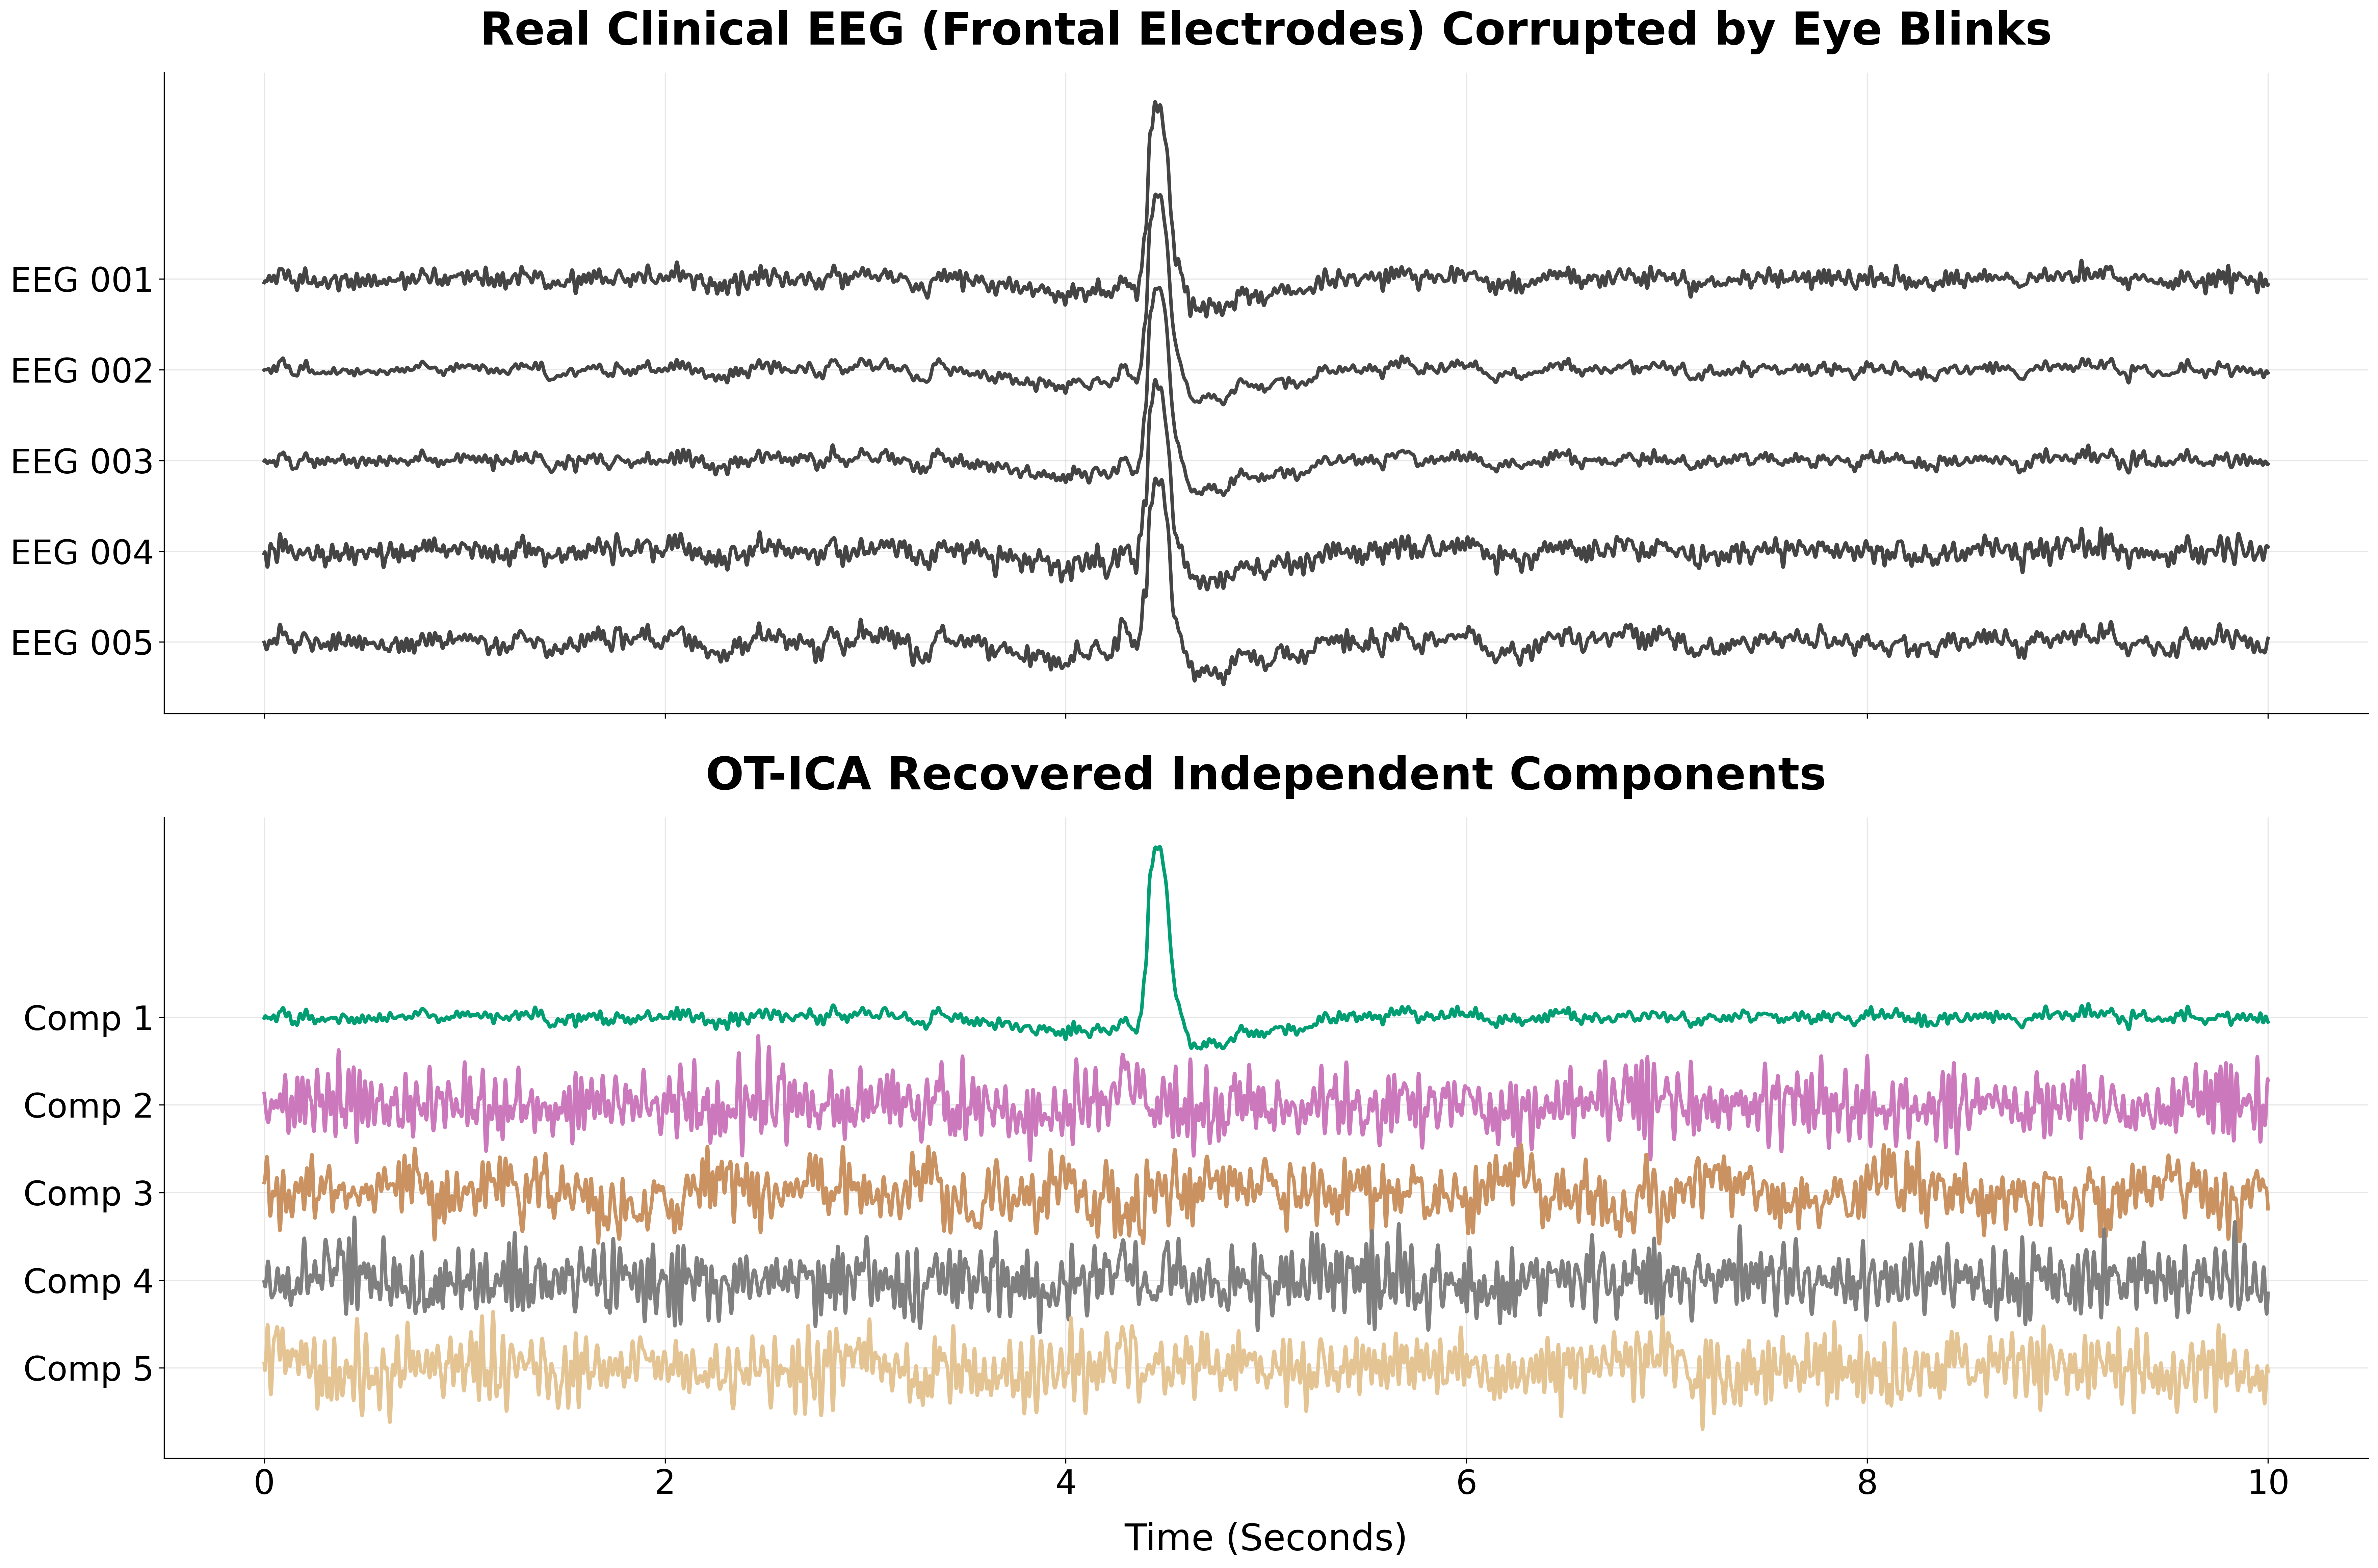

Takeaway: The massive, synchronized spikes spanning all frontal channels (the eye-blinks) have been perfectly isolated into a single independent component, successfully cleaning the underlying continuous brain waves in the other components.


In [4]:
# ==========================================
# 4. Massive Visualization Settings
# ==========================================
TITLE_FS = 32
LABEL_FS = 26
TICK_FS = 24

fig, axes = plt.subplots(2, 1, figsize=(24, 16), sharex=True)

# Colorblind-friendly colors explicitly excluding Blue and Orange
# Uses Green, Purple, Brown, Dark Grey, and Beige
colors = ['#029E73', '#CC78BC', '#CA9161', '#7F7F7F', '#E5C494']

# Plot A: Real Scalp EEG Electrodes (Corrupted by Blinks)
for i in range(dim):
    # Offset by i*5 to stack the signals vertically
    axes[0].plot(time, X_real[i] - i*5, color='#444444', linewidth=2.5) # Dark grey for raw signals
axes[0].set_title("Real Clinical EEG (Frontal Electrodes) Corrupted by Eye Blinks", fontsize=TITLE_FS, fontweight='bold', pad=20)
axes[0].set_yticks([-20, -15, -10, -5, 0])
axes[0].set_yticklabels(frontal_channels[::-1], fontsize=TICK_FS) 
axes[0].tick_params(axis='x', labelsize=TICK_FS)

# Plot B: OT-ICA Recovered Components
for i in range(dim):
    # Offset by i*5 to stack the signals vertically
    axes[1].plot(time, Z_hat[i] - i*5, color=colors[i], linewidth=2.5)
axes[1].set_title("OT-ICA Recovered Independent Components", fontsize=TITLE_FS, fontweight='bold', pad=20)
axes[1].set_yticks([-20, -15, -10, -5, 0])
axes[1].set_yticklabels([f'Comp {i+1}' for i in range(dim)][::-1], fontsize=TICK_FS)
axes[1].set_xlabel("Time (Seconds)", fontsize=LABEL_FS, labelpad=15)
axes[1].tick_params(axis='x', labelsize=TICK_FS)

plt.tight_layout()

# Save as a high-quality PDF specifically for LaTeX rendering
file_name = 'eeg_artifact_removal.pdf'
plt.savefig(file_name, format='pdf', bbox_inches='tight')
print(f"Successfully saved huge figure to {file_name}")

plt.show()

print("Takeaway: The massive, synchronized spikes spanning all frontal channels (the eye-blinks) have been perfectly isolated into a single independent component, successfully cleaning the underlying continuous brain waves in the other components.")